## Calculate rainfall exceedance thresholds for Storm Desmond from ERA5

In [1]:
import os
import itertools
import logging

import math
from datetime import timedelta, datetime

import numpy as np
import xarray as xr
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

import matplotlib as mpl
from matplotlib.colors import ListedColormap
try:
    # MetPy import (works for different MetPy versions)
    from metpy.plots import ctables
except Exception as exc:
    raise ImportError("MetPy is required to use MetPy color tables") from exc

import metpy.plots.ctables as mp
sns.set_theme()

/home/jbanorthwest.co.uk/samhardy/miniforge3/envs/earth2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Code from the Python functions that Kay shared

In [2]:
LOGGER = logging.getLogger(__name__)
LOGGER.addHandler(logging.NullHandler())

# netcdf variable names for output datasets
X_VAR = "projection_x_coordinate"
Y_VAR = "projection_y_coordinate"
TIME_VAR = "time"
TIME_BOUNDS_VAR = "time_bnds"
ACC_VAR = "accumulation_period"
RP_VAR = "return_period"
THRESHOLD_EXCEEDED_VAR = "ensembles_exceeding_threshold"
TOTAL_ENSEMBLES_VAR = "total_ensembles"

THRESHOLD_EXCEEDED_DTYPE = np.uint8  # may need to be uint16 if more than 255 ensembles.
                                     # this is okay for now. mogreps = 216 ensembles, ireps = 198

In [ ]:
# def calculate_accumulations(etl_config, ds):
#     """ Calculates accumulations of rainfall over a set number of accumulation periods.  Essentially sums up the
#     rolling windows of rainfall
#     """
#     accumulations = []

#     for hours in etl_config.threshold_acc_periods:
#         accumulation = ds[etl_config.rain_var].rolling({etl_config.time_var: hours}).sum(min_count=hours, skipna=True)
#         # for some reason, chunks get a bit messed up (e.g. for time length of 126, chunk would get set to 123)
#         #   explicitly set to None to 'reset' the chunk
#         accumulation = accumulation.chunk({etl_config.time_var: None})
#         accumulations.append(accumulation)

#     # concatenate the accumulation data together, creating a new dimension of 'accumulation_period'
#     accumulation_arr = xr.concat(accumulations, ACC_VAR)
#     ds[etl_config.rain_var] = accumulation_arr

#     ds = ds.assign_coords({ACC_VAR: etl_config.thresholds[ACC_VAR].values})  # add the dimension as a variable

#     return ds


def calculate_threshold_exceedance(etl_config, ds):
    """ Determines how many of the dataset rainfall ensembles have exceeded pre-calculated return period thresholds.
    Thresholds have been calculated for specific return period and accumulation period combinations
    """
    # note, rainfall_accumulation could contain NAN (due to not enough time steps for accumulations early on in array)
    # the gte comparison will cause a runtime warning: invalid value encountered in greater_equal, but can just
    # ignore this
    thresholds_exceeded = ds[etl_config.rain_var] >= etl_config.thresholds[etl_config.threshold_rain_var]

    num_ensembles_exceeded = thresholds_exceeded.sum(dim=etl_config.ensemble_var)

    # explicitly stating dtype helps performance
    ds[etl_config.rain_var] = num_ensembles_exceeded
    ds[etl_config.rain_var] = ds[etl_config.rain_var].astype(THRESHOLD_EXCEEDED_DTYPE)

    ds = ds.rename({etl_config.rain_var: THRESHOLD_EXCEEDED_VAR})
    if etl_config.ensemble_var in ds.dims:
        ds = ds.drop(etl_config.ensemble_var)

    return ds

## Read in the ERA5 data and aggregate to 24-h accumulations

In [4]:
def normalise_longitude(ds: xr.Dataset, 
                        lon_name='lon'):
    """ 
    Convert longitude from [0...360] to [-180...180] if necessary and sort the dataset by longitude.
    This ensures that the longitude coordinates are in a consistent format for plotting and analysis, 
    especially when working with global datasets that may use different longitude conventions. 
    """
    lon = ds[lon_name]
    if float(lon.max()) > 180:
        # map 0..360 -> -180..180 and re-sort
        ds = ds.assign_coords({lon_name: ((lon + 180) % 360) - 180}).sortby(lon_name)
    return ds

def preprocess_era5_rainfall(ds: xr.Dataset,
                             rolling_window: int,
                             min_periods: int,
                             lead_dim='valid_time'):
    """ 
    Pre-process ERA5 rainfall data to be in the correct format for calculating threshold exceedance. This includes:
        - renaming variables and dimensions to match the expected names in the ETL config
        - converting units from m to mm
    """
    #ds = normalise_longitude(ds, lon_name='longitude') # TODO: make lon_name a parameter in case different datasets use different names for longitude

    # check for singleton time dimensions and squeeze 
    # singleton_dims = [dim for dim, size in ds.sizes.items() if size == 1] 
    singleton_dims = [] 
    for dim, size in ds.sizes.items():
        if size == 1:
            singleton_dims.append(dim)
    if 'time' in singleton_dims:
        ds = ds.squeeze(dim='time')

    # change units of precip from 'm' to 'mm'
    # TODO: generalise for different variable names and units, e.g. by passing in the variable name and expected input and output units as parameters
    da_pr = ds['tp'] * 1000.0

    if rolling_window is not None:
        if lead_dim is None:
            raise ValueError("Cannot compute rolling window without a lead/time dimension.")
        # rolling produces same-length lead dimension with NaNs in first (rolling_window-1) positions
        da_pr24 = da_pr.rolling({lead_dim: rolling_window}, min_periods=min_periods).sum()
    else:
        # assume da_s already is 24h totals with a lead_dim
        da_pr24 = da_pr

    # select 24-h period between 00Z 5 and 00Z 6 Dec 2015 (inclusive)
    da_pr24 = da_pr24.sel(valid_time=('2015-12-06T00'))

    return da_pr24

def get_metpy_colourmap(name='precipitation'):
    """
    Return a matplotlib Colormap object for a MetPy colortable name.
    Handles several MetPy API return formats.
    """
    cmap_src = None
    # try possible APIs
    if hasattr(ctables, 'get_colortable'):
        cmap_src = ctables.get_colortable(name)        # newer API sometimes returns colormap or list
    elif isinstance(ctables, dict) and name in ctables:
        cmap_src = ctables[name]                       # older API returns list or tuple
    else:
        # try other attributes (some versions expose colortables dict)
        try:
            cmap_src = ctables.colortables[name]
        except Exception:
            raise KeyError(f"Could not find MetPy colortable '{name}' in this MetPy version")

    # If MetPy already returned a Colormap, use it
    if isinstance(cmap_src, mpl.colors.Colormap):
        return cmap_src

    # If it returned a tuple like (colors, bounds), extract colors
    if isinstance(cmap_src, tuple) and len(cmap_src) >= 1:
        colors = cmap_src[0]
    else:
        colors = cmap_src

    # Convert colors to numpy array
    colors = np.asarray(colors)

    # If colors are Nx3 or Nx4 integer 0..255, scale to 0..1
    if np.issubdtype(colors.dtype, np.integer):
        if colors.max() > 1:
            colors = colors.astype(float) / 255.0

    # If colors are Nx3 or Nx4 floats already 0..1, accept
    # If colors are hex strings, ListedColormap can handle them directly

    # Finally create a ListedColormap
    try:
        cmap = ListedColormap(colors, name=name)
    except Exception:
        # Fallback: try converting each color to an mpl color string
        cmap = ListedColormap([mpl.colors.to_rgba(c) for c in colors], name=name)

    # set NaN color, under/over if you like
    cmap.set_bad('lightgray')   # NaNs
    cmap.set_under('white')     # < vmin
    cmap.set_over('black')      # > vmax

    return cmap

# Call the functions 
ds = xr.open_dataset('/mnt/metdata/2025s1985/era5/hourly_surface/tp/reanalysis-era5-single-levels_2015_month12.nc')
da_pr24 = preprocess_era5_rainfall(ds, rolling_window=24, min_periods=24, lead_dim='valid_time')

## Produce a formatted plot over the UK and Ireland

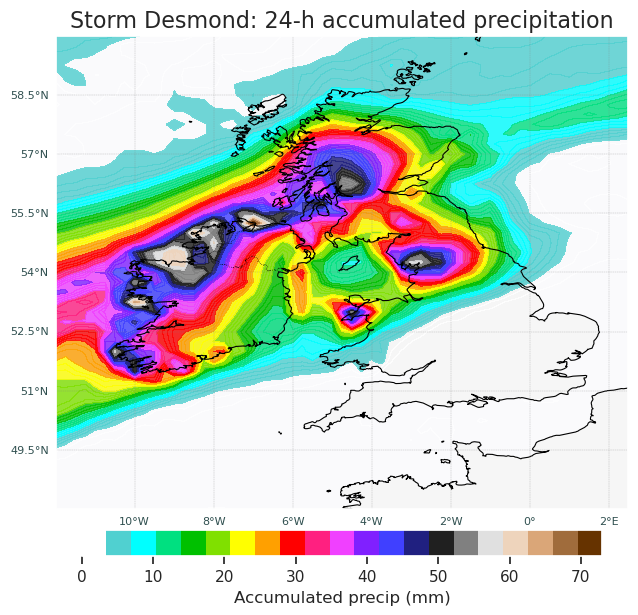

In [10]:
crs = ccrs.PlateCarree()
cmap = get_metpy_colourmap('precipitation')

# restrict to UK and Ireland region for plotting
uk_lat_bounds = [60.0, 48.0] # ERA5 only extends to 60N, so match that value 
uk_lon_bounds = [-12, 2.5]

# subset to cover only UK and Ireland grid points 
da_pr24 = da_pr24.sel(latitude=slice(uk_lat_bounds[0],uk_lat_bounds[1]),
                      longitude=slice(uk_lon_bounds[0],uk_lon_bounds[1]))

# extract latitude/longitude arrays 
try:
    lon = da_pr24['lon'].values
except Exception: 
    lon = da_pr24['longitude'].values

try:
    lat = da_pr24['lat'].values
except Exception:
    lat = da_pr24['latitude'].values

# create 2D lat + lon arrays 
Lon, Lat = np.meshgrid(lon, lat)

# common function to add coastal features
def decorate(ax):
    #ax.set_extent(extent, crs=crs)
    ax.coastlines(resolution='10m', linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
    ax.add_feature(cfeature.LAND.with_scale('10m'), facecolor='lightgray', zorder=0)


# create a 'panel' plot with a single panel
fig, axes = plt.subplots(figsize=(9, 6),
                         subplot_kw={'projection': crs})

# Mean sea level pressure (pmsl)
ax = axes
decorate(ax)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.6, linestyle='--')
# remove lat-lon labels on top and right axes 
try:
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = True
    gl.left_labels = True
except AttributeError:
    gl.xlabels_top = False
    gl.xlabels_bottom = True
    gl.ylabels_left = False
    gl.ylabels_right = True

gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# make the lat/lon labels smaller and lighter
gl.xlabel_style = {'size': 8, 'color': 'darkslategray'}
gl.ylabel_style = {'size': 8, 'color': 'darkslategray'}

# repeat for precip
pr = da_pr24.values.copy()
pr_min = np.nanmin(pr)
pr_max = np.nanmax(pr)
interval = 1.0
lev_min = np.floor(pr_min / interval)
lev_max = np.ceil(pr_max / interval)
pr_levels = np.arange(lev_min * interval, lev_max * interval + 1e-6, interval)

# also filled contour plot for precip
cs_pr = ax.contourf(Lon, Lat, pr, levels=pr_levels, cmap=cmap, alpha=0.8, transform=crs)
ax.set_title(f'Storm Desmond: 24-h accumulated precipitation',fontsize=16)
plt.tight_layout()

# add and customise colourbar 
norm = mcolors.Normalize(vmin=lev_min, vmax=lev_max)
sm = ScalarMappable(norm=norm, cmap=cmap)  # only used for colorbar scaling if you want
sm.set_array([])
# place colorbar below the whole figure
cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.05, pad=0.04)
cbar.set_label('Accumulated precip (mm)')

out_file = f'/mnt/metdata/2025s1985/output_plots/ERA5_Desmond_24h_prcp.png'
plt.savefig(out_file, dpi=300, bbox_inches='tight', pad_inches=0)

## Read in the 24-h accumulated rainfall return levels

In [14]:
return_levels_24h = xr.open_dataset('/mnt/metdata/2025s1985/era5_eva/24h/UKI_return_levels_24h_WY1980-2021.nc')
return_levels_24h['return_level'] = return_levels_24h['return_level'] * 1000.0  # convert from m to mm

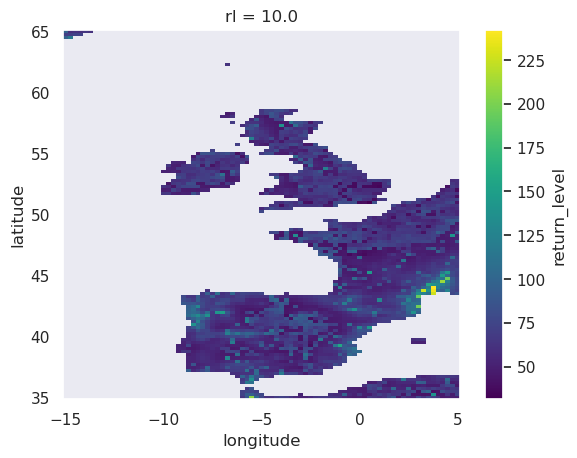

In [15]:
return_levels_24h['return_level'].sel(rl=10).plot()